# Signature Verification — Plain CNN (Baseline)

First attempt: treat verification as plain image classification. We stack the two signatures
into a single 2-channel image and let one CNN decide genuine vs forged.

This is the naive approach. It works but doesn't really learn what makes two signatures
*similar* — that's what we fix with a Siamese network in notebook 2.

**Techniques used:** Conv2D, BatchNorm, Dropout, GlobalAveragePooling, Adam, EarlyStopping, ReduceLROnPlateau

## 1. Imports

In [2]:
import os
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

import tensorflow as tf
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report, roc_auc_score

## 2. Get the Dataset

On Colab, clone the project repo — the dataset ships inside it. Locally, just point DATA_ROOT at the sign_data folder.

In [3]:
# clone the project repo (run once) — the dataset ships inside it
!git clone https://github.com/goyashek/Signature-forgery-verification.git

DATA_ROOT = 'Signature-forgery-verification/sign_data'
IMG_DIR   = os.path.join(DATA_ROOT, 'train')   # all writers live here

IMG_H, IMG_W = 150, 220

fatal: destination path 'Signature-forgery-verification' already exists and is not an empty directory.


## 3. Build a writer-independent split

Heads up: the dataset's `test/` folder is just a duplicate copy of part of `train/` (same files,
same names). If we tested on it we'd basically be testing on training data.

So instead we split by **writer id**. The model trains on some people and is tested on people it
has never seen — which is the whole point of a verification system.

- train: writers 001-040
- val:   writers 041-048
- test:  writers 049-069

In [4]:
# the two csvs together cover all the pairs; combine and drop duplicates
cols = ['img1', 'img2', 'label']
df = pd.concat([pd.read_csv(os.path.join(DATA_ROOT, 'train_data.csv'), header=None, names=cols),
                pd.read_csv(os.path.join(DATA_ROOT, 'test_data.csv'),  header=None, names=cols)])
df = df.drop_duplicates().reset_index(drop=True)

# writer id is the folder part of the first image, e.g. '068/09_068.png' -> 68
df['writer'] = df['img1'].str.split('/').str[0].astype(int)

train_df = df[df['writer'] <= 40]
val_df   = df[(df['writer'] >= 41) & (df['writer'] <= 48)]
test_df  = df[df['writer'] >= 49]

print('train pairs:', len(train_df))
print('val pairs:  ', len(val_df))
print('test pairs: ', len(test_df))

train pairs: 15298
val pairs:   2160
test pairs:  5748


## 4. Load the images

label meaning in the csv: **0 = genuine pair (match), 1 = forged pair**.

There are a lot of pairs, so we take a balanced sample to keep memory and training time sane on
Colab. We load both signatures in grayscale, resize, and stack them into one (H, W, 2) image.

In [5]:
def sample_balanced(frame, n):
    # equal-ish number of genuine and forged pairs
    g = frame[frame.label == 0].sample(min(n//2, sum(frame.label==0)), random_state=42)
    f = frame[frame.label == 1].sample(min(n//2, sum(frame.label==1)), random_state=42)
    return pd.concat([g, f]).sample(frac=1, random_state=42)

train_s = sample_balanced(train_df, 8000)
val_s   = sample_balanced(val_df,   2000)
test_s  = sample_balanced(test_df,  3000)

In [6]:
def load_stacked(frame):
    X, y = [], []
    for _, row in frame.iterrows():
        a = cv2.imread(os.path.join(IMG_DIR, row['img1']), cv2.IMREAD_GRAYSCALE)
        b = cv2.imread(os.path.join(IMG_DIR, row['img2']), cv2.IMREAD_GRAYSCALE)
        a = cv2.resize(a, (IMG_W, IMG_H))
        b = cv2.resize(b, (IMG_W, IMG_H))
        X.append(np.stack([a, b], axis=-1))   # (H, W, 2)
        y.append(row['label'])
    return np.array(X), np.array(y)

X_train, y_train = load_stacked(train_s)
X_val,   y_val   = load_stacked(val_s)
X_test,  y_test  = load_stacked(test_s)

# normalize pixels to [0, 1]
X_train = X_train.astype('float32') / 255.0
X_val   = X_val.astype('float32') / 255.0
X_test  = X_test.astype('float32') / 255.0

print('X_train:', X_train.shape)
print('X_test: ', X_test.shape)

X_train: (8000, 150, 220, 2)
X_test:  (3000, 150, 220, 2)


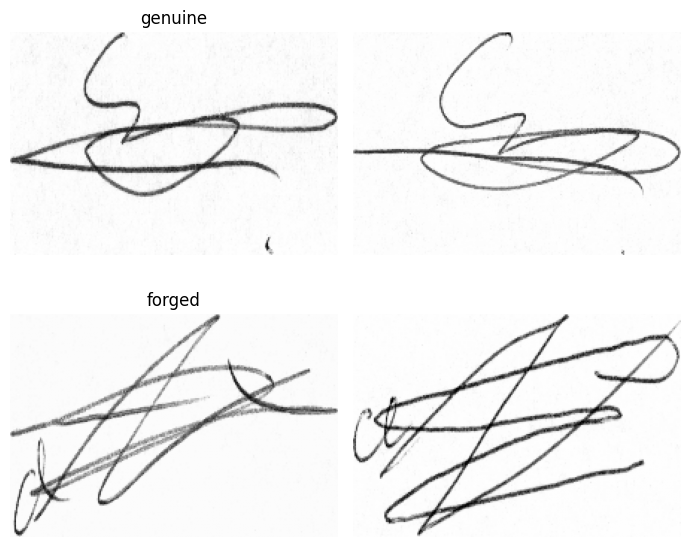

In [7]:
# quick look at a genuine pair and a forged pair
fig, axes = plt.subplots(2, 2, figsize=(7, 6))
for ax_row, lbl in zip(axes, [0, 1]):
    idx = np.where(y_train == lbl)[0][0]
    ax_row[0].imshow(X_train[idx, :, :, 0], cmap='gray')
    ax_row[1].imshow(X_train[idx, :, :, 1], cmap='gray')
    ax_row[0].set_title('genuine' if lbl == 0 else 'forged')
    ax_row[0].axis('off'); ax_row[1].axis('off')
plt.tight_layout(); plt.show()

## 5. Build the CNN

3 conv blocks (32 -> 64 -> 128), each Conv + BatchNorm + MaxPool. GlobalAveragePooling instead of
Flatten, then a dense layer with dropout and a sigmoid output.

In [8]:
model = Sequential()

model.add(Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(IMG_H, IMG_W, 2)))
model.add(BatchNormalization())
model.add(MaxPooling2D((2, 2)))

model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D((2, 2)))

model.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D((2, 2)))

model.add(GlobalAveragePooling2D())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(1, activation='sigmoid'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 150, 220, 32)   │           608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 150, 220, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 110, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 110, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 75, 110, 64)    │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 55, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 37, 55, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 37, 55, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 27, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,497 (431.63 KB)

 Trainable params: 110,049 (429.88 KB)

 Non-trainable params: 448 (1.75 KB)

## 6. Compile & Train

In [9]:
model.compile(optimizer=Adam(1e-3), loss='binary_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr  = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)

history = model.fit(X_train, y_train,
                    validation_data=(X_val, y_val),
                    epochs=20, batch_size=32,
                    callbacks=[early_stop, reduce_lr])

Epoch 1/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 23s 56ms/step - accuracy: 0.8984 - loss: 0.2305 - val_accuracy: 0.5000 - val_loss: 0.9578 - learning_rate: 0.0010
Epoch 2/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 11s 43ms/step - accuracy: 0.9676 - loss: 0.0892 - val_accuracy: 0.6475 - val_loss: 0.7428 - learning_rate: 0.0010
Epoch 3/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 11s 43ms/step - accuracy: 0.9865 - loss: 0.0425 - val_accuracy: 0.8325 - val_loss: 0.3704 - learning_rate: 0.0010
Epoch 4/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 11s 44ms/step - accuracy: 0.9898 - loss: 0.0305 - val_accuracy: 0.6275 - val_loss: 1.2287 - learning_rate: 0.0010
Epoch 5/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 11s 44ms/step - accuracy: 0.9908 - loss: 0.0273 - val_accuracy: 0.8940 - val_loss: 0.2105 - learning_rate: 0.0010
Epoch 6/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 11s 44ms/step - accuracy: 0.9948 - loss: 0.0169 - val_accuracy: 0.9175 - val_loss: 0.2607 - learning_rate: 0.0010
Epoch 7/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 21s 45ms/step - accuracy: 0.9949 - l

## 7. Evaluate on unseen writers

In [10]:
y_prob = model.predict(X_test).ravel()
y_pred = (y_prob > 0.5).astype(int)

print(classification_report(y_test, y_pred, target_names=['genuine', 'forged']))
print('ROC-AUC:', round(roc_auc_score(y_test, y_prob), 3))

94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step
              precision    recall  f1-score   support

     genuine       0.99      0.99      0.99      1500
      forged       0.99      0.99      0.99      1500

    accuracy                           0.99      3000
   macro avg       0.99      0.99      0.99      3000
weighted avg       0.99      0.99      0.99      3000

ROC-AUC: 0.999


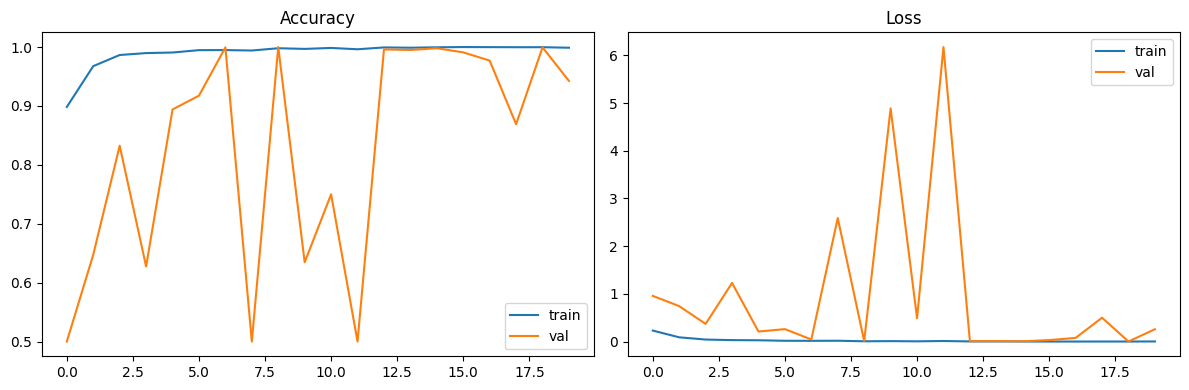

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history.history['accuracy'], label='train')
ax1.plot(history.history['val_accuracy'], label='val')
ax1.set_title('Accuracy'); ax1.legend()
ax2.plot(history.history['loss'], label='train')
ax2.plot(history.history['val_loss'], label='val')
ax2.set_title('Loss'); ax2.legend()
plt.tight_layout(); plt.show()

## 8. Takeaways

- A plain CNN on stacked pairs does learn something, but it tends to struggle on writers it
  never saw during training.
- The problem: by fusing both signatures at the very first layer, it never learns a real notion
  of *similarity* — it just memorizes what training pairs look like.
- It also can't handle a brand new person without retraining the whole thing.
- **Next:** a Siamese network runs each signature through the same CNN to get an embedding, then
  compares them by distance. That generalizes to new writers and is the right tool for the job.